# Projeto: [Nome do Projeto de Análise de Dados]

**Disciplina:** Análise de dados

**Instituição:** Faculdade Engenheiro Salvador Arena

**Data:** 04 de Março de 2026 | **Versão:** 1.0  



---



### Descrição Executiva

Este notebook contempla a etapa de **Engenharia de Dados (M1)**. O objetivo é estabelecer um pipeline automatizado que consome dados de dataset público **“Fuel Economy Data: How Efficient Are Today’s Cars?”**, disponibilizado na plataforma Kaggle, realiza o tratamento de integridade e estrutura os dados sob a arquitetura de **Star Schema** para otimização de consultas analíticas.



### Equipe

* **Integrante 1:** Ivan Luiz Picolotte dos Santos - 082210015

* **Integrante 2:** Rafael Yukio Ivasa - 082210011



### Stack Tecnológica

* **Linguagem:** Python 3.x

* **Bibliotecas Principais:** Pandas, NumPy, [Outras]

* **Ambiente:** Google Colab + Google Drive (Storage)



### Estrutura de Diretórios Esperada (Drive)

- `Project_Root/`

    - `data/`

        - `raw/` (Dados originais sem modificação)

        - `processed/` (Tabelas Fato e Dimensão prontas para uso)

## Introdução
Este projeto utiliza o dataset Fuel Economy Data, que contém informações sobre eficiência energética de veículos modernos, incluindo consumo de combustível, tipo de motor, fabricante e características técnicas.

O objetivo é construir um pipeline de ETL que transforma os dados brutos em um modelo dimensional no formato Star Schema, permitindo análises como:


*   Comparação de eficiência entre fabricantes
*   Impacto do tipo de combustível no consumo
*   Evolução da eficiência ao longo dos anos

# M1 - Engenharia de Dados (ETL)

### ETAPA 1 — EXTRACT

In [2]:
# Instalar e configurar Kaggle
!pip install kaggle

In [3]:
from google.colab import files
files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [4]:
# Baixar dataset
!kaggle datasets download -d thedevastator/fuel-economy-data-how-efficient-are-today-s-cars
!unzip fuel-economy-data-how-efficient-are-today-s-cars.zip

Dataset URL: https://www.kaggle.com/datasets/thedevastator/fuel-economy-data-how-efficient-are-today-s-cars
License(s): other
100% 1.47M/1.47M [00:00<00:00, 27.7MB/s]

Archive:  fuel-economy-data-how-efficient-are-today-s-cars.zip
  inflating: vehicles.csv            


In [5]:
# Carregar dados
import pandas as pd

df_raw = pd.read_csv('vehicles.csv')
df_raw.head()

/tmp/ipykernel_55211/3015019867.py:4: DtypeWarning: Columns (71,72,73,74,75,77,80) have mixed types. Specify dtype option on import or set low_memory=False.
  df_raw = pd.read_csv('vehicles.csv')


,index,barrels08,barrelsA08,charge120,charge240,city08,city08U,cityA08,cityA08U,cityCD,...,mfrCode,c240Dscr,charge240b,c240bDscr,createdOn,modifiedOn,startStop,phevCity,phevHwy,phevComb
0,0,15.695714,0.0,0.0,0.0,19,0.0,0,0.0,0.0,...,NaN,NaN,0.0,NaN,Tue Jan 01 00:00:00 EST 2013,Tue Jan 01 00:00:00 EST 2013,NaN,0,0,0
1,1,29.964545,0.0,0.0,0.0,9,0.0,0,0.0,0.0,...,NaN,NaN,0.0,NaN,Tue Jan 01 00:00:00 EST 2013,Tue Jan 01 00:00:00 EST 2013,NaN,0,0,0
2,2,12.207778,0.0,0.0,0.0,23,0.0,0,0.0,0.0,...,NaN,NaN,0.0,NaN,Tue Jan 01 00:00:00 EST 2013,Tue Jan 01 00:00:00 EST 2013,NaN,0,0,0
3,3,29.964545,0.0,0.0,0.0,10,0.0,0,0.0,0.0,...,NaN,NaN,0.0,NaN,Tue Jan 01 00:00:00 EST 2013,Tue Jan 01 00:00:00 EST 2013,NaN,0,0,0
4,4,17.347895,0.0,0.0,0.0,17,0.0,0,0.0,0.0,...,NaN,NaN,0.0,NaN,Tue Jan 01 00:00:00 EST 2013,Tue Jan 01 00:00:00 EST 2013,NaN,0,0,0


In [6]:
# Salvar RAW no Drive
from google.colab import drive
drive.mount('/content/drive')

import os

base_path = '/content/drive/MyDrive/Project_Root/data'
raw_path = os.path.join(base_path, 'raw')
processed_path = os.path.join(base_path, 'processed')

os.makedirs(raw_path, exist_ok=True)
os.makedirs(processed_path, exist_ok=True)

df_raw.to_csv(f"{raw_path}/fuel_raw.csv", index=False)

Mounted at /content/drive


### ETAPA 2 — TRANSFORM

In [7]:
df = df_raw.copy()

# Remover duplicatas
df = df.drop_duplicates()

# Verificar nulos
df.isnull().sum()

,0
index,0
barrels08,0
barrelsA08,0
charge120,0
charge240,0
...,...
modifiedOn,0
startStop,31670
phevCity,0
phevHwy,0


In [8]:
df = df.fillna({
    'fuelType': 'Unknown',
    'make': 'Unknown'
})
df = df.dropna(subset=['city08', 'highway08', 'comb08'])
df = df.rename(columns={
    'city08': 'consumo_cidade',
    'highway08': 'consumo_rodovia',
    'comb08': 'consumo_combinado'
})

In [9]:
# Ajustes de tipo
df['year'] = df['year'].astype(int)

### MODELAGEM DIMENSIONAL

In [10]:
# Dimensão Veículo
dim_vehicle = df[['make', 'model', 'year']].drop_duplicates().reset_index(drop=True)
dim_vehicle['vehicle_id'] = dim_vehicle.index
# Dimensão Combustível
dim_fuel = df[['fuelType']].drop_duplicates().reset_index(drop=True)
dim_fuel['fuel_id'] = dim_fuel.index
# Dimensão Tempo
dim_year = df[['year']].drop_duplicates().reset_index(drop=True)
dim_year['year_id'] = dim_year.index
# Tabelas Fato
# Consumo
df = df.merge(dim_fuel, on='fuelType')
df = df.merge(dim_vehicle, on=['make', 'model', 'year'])
df = df.merge(dim_year, on='year')
fact_fuel = df[['vehicle_id', 'fuel_id', 'year_id', 'consumo_cidade', 'consumo_rodovia', 'consumo_combinado']]

### ETAPA 3 — LOAD

In [11]:
fact_fuel.to_csv(f"{processed_path}/fact_fuel.csv", index=False)
dim_vehicle.to_csv(f"{processed_path}/dim_vehicle.csv", index=False)
dim_fuel.to_csv(f"{processed_path}/dim_fuel.csv", index=False)
dim_year.to_csv(f"{processed_path}/dim_year.csv", index=False)

# M2 — Análise Exploratória de Dados (EDA)

Nesta etapa, realizamos a análise estatística e visual dos dados processados, com o objetivo de extrair insights e apoiar decisões para modelagem futura.



In [12]:
target = 'consumo_combinado'

In [13]:
df.describe()

,index,barrels08,barrelsA08,charge120,charge240,consumo_cidade,city08U,cityA08,cityA08U,cityCD,...,UHighwayA,year,youSaveSpend,charge240b,phevCity,phevHwy,phevComb,fuel_id,vehicle_id,year_id
count,37936.000000,37936.000000,37936.000000,37936.0,37936.000000,37936.000000,37936.000000,37936.000000,37936.000000,37936.000000,...,37936.000000,37936.000000,37936.000000,37936.000000,37936.000000,37936.000000,37936.000000,37936.000000,37936.000000,37936.000000
mean,18967.500000,17.538963,0.217321,0.0,0.023810,17.930515,4.493563,0.529866,0.370943,0.000405,...,0.948227,2000.116169,-2757.716944,0.004349,0.073729,0.072385,0.072860,0.566955,8223.678221,17.086409
std,10951.324243,4.561923,1.142724,0.0,0.429744,6.653219,9.884303,3.928061,3.689534,0.039869,...,6.165548,10.425750,2564.898655,0.142601,2.044186,1.939572,1.985877,1.248296,5167.914563,9.790868
min,0.000000,0.060000,0.000000,0.0,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,1984.000000,-22500.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,9483.750000,14.330870,0.000000,0.0,0.000000,15.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,1991.000000,-4500.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3597.000000,9.000000
50%,18967.500000,17.347895,0.000000,0.0,0.000000,17.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,2001.000000,-2500.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8198.500000,18.000000
75%,28451.250000,20.600625,0.000000,0.0,0.000000,20.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,2009.000000,-1000.000000,0.000000,0.000000,0.000000,0.000000,1.000000,12779.000000,25.000000
max,37935.000000,47.087143,18.311667,0.0,12.000000,138.000000,138.304000,127.000000,127.093000,5.350000,...,152.187800,2017.000000,4000.000000,7.000000,97.000000,81.000000,88.000000,13.000000,17098.000000,33.000000


In [14]:
df[target].mean()

np.float64(20.16564740615774)

In [15]:
df[target].median()

19.0

In [16]:
df[target].mode()

,consumo_combinado
0,18


In [17]:
df[target].std()

6.59162405053237

In [18]:
df[target].var()

43.44950762355676

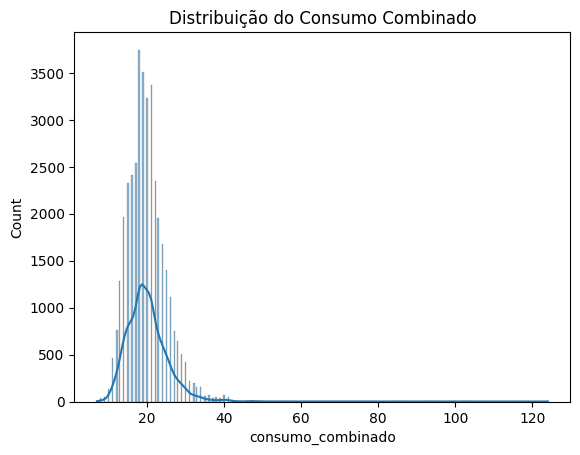

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df[target], kde=True)
plt.title("Distribuição do Consumo Combinado")
plt.show()

Observa-se a distribuição da variável alvo, permitindo identificar a presença de assimetria e concentração de valores.

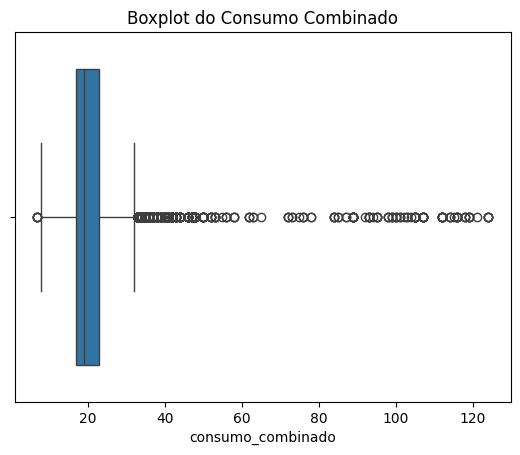

In [20]:
sns.boxplot(x=df[target])
plt.title("Boxplot do Consumo Combinado")
plt.show()

In [21]:
q1 = df[target].quantile(0.25)
q3 = df[target].quantile(0.75)
iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

outliers = df[(df[target] < lower) | (df[target] > upper)]
len(outliers)

873

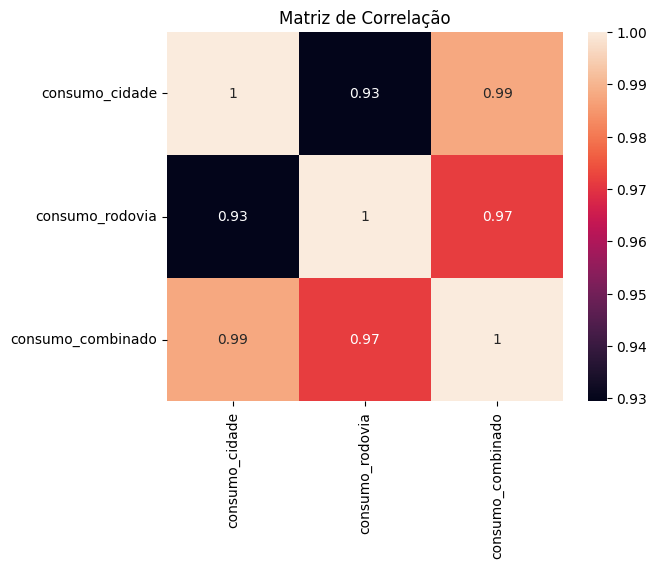

In [22]:
corr = df[['consumo_cidade', 'consumo_rodovia', 'consumo_combinado']].corr()

sns.heatmap(corr, annot=True)
plt.title("Matriz de Correlação")
plt.show()

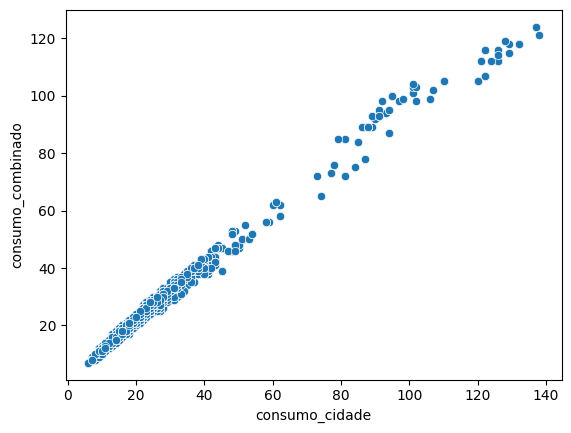

In [23]:
sns.scatterplot(x='consumo_cidade', y='consumo_combinado', data=df)
plt.show()

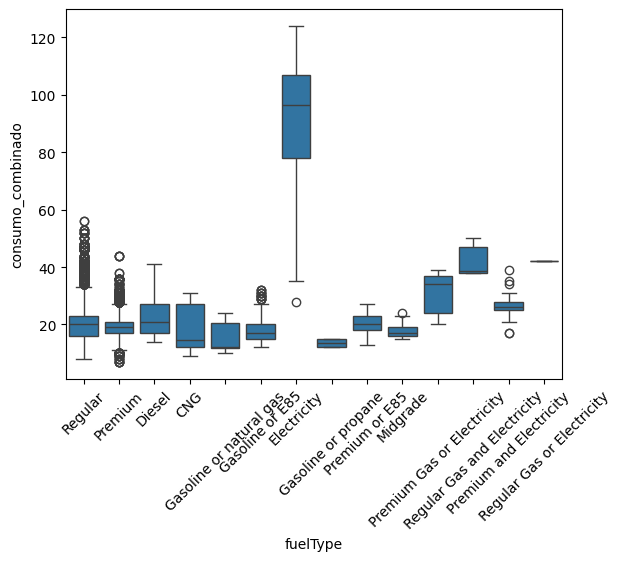

In [24]:
sns.boxplot(x='fuelType', y='consumo_combinado', data=df)
plt.xticks(rotation=45)
plt.show()

## Conclusões para Modelagem

Com base na análise exploratória, observa-se que:

- A variável alvo apresenta distribuição (simétrica/assimétrica), podendo exigir normalização.
- Existem variáveis altamente correlacionadas, o que pode indicar redundância.
- A presença de possíveis outliers deve ser considerada na modelagem.
- A relação entre variáveis sugere que modelos lineares podem ser aplicáveis, mas modelos não-lineares também devem ser considerados.

Dessa forma, recomenda-se a aplicação inicial de modelos de regressão linear, seguida da avaliação de modelos baseados em árvores.

# M3 — Modelagem Preditiva

In [25]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Identificar colunas categóricas e numéricas
categorical_features = df.select_dtypes(include=['object']).columns
numeric_features = df.select_dtypes(include=['int64', 'float64']).columns.drop(['fuel_id', 'vehicle_id', 'year_id', 'index'])

# Remover o target das features numéricas
numeric_features = numeric_features.drop(target, errors='ignore')

print(f"Categorical features: {list(categorical_features)}")
print(f"Numeric features: {list(numeric_features)}")


Categorical features: ['drive', 'eng_dscr', 'fuelType', 'fuelType1', 'make', 'model', 'mpgData', 'trany', 'VClass', 'guzzler', 'trans_dscr', 'tCharger', 'sCharger', 'atvType', 'fuelType2', 'rangeA', 'evMotor', 'mfrCode', 'c240Dscr', 'c240bDscr', 'createdOn', 'modifiedOn', 'startStop']
Numeric features: ['barrels08', 'barrelsA08', 'charge120', 'charge240', 'consumo_cidade', 'city08U', 'cityA08', 'cityA08U', 'cityCD', 'cityE', 'cityUF', 'co2', 'co2A', 'co2TailpipeAGpm', 'co2TailpipeGpm', 'comb08U', 'combA08', 'combA08U', 'combE', 'combinedCD', 'combinedUF', 'cylinders', 'displ', 'engId', 'feScore', 'fuelCost08', 'fuelCostA08', 'ghgScore', 'ghgScoreA', 'consumo_rodovia', 'highway08U', 'highwayA08', 'highwayA08U', 'highwayCD', 'highwayE', 'highwayUF', 'hlv', 'hpv', 'id', 'lv2', 'lv4', 'pv2', 'pv4', 'range', 'rangeCity', 'rangeCityA', 'rangeHwy', 'rangeHwyA', 'UCity', 'UCityA', 'UHighway', 'UHighwayA', 'year', 'youSaveSpend', 'charge240b', 'phevCity', 'phevHwy', 'phevComb']


### Pré-processamento Final (Feature Engineering, Escalonamento e Divisão de Dados)

Agora que identificamos as colunas categóricas e numéricas, vamos aplicar o pré-processamento:
*   **One-Hot Encoding** para as variáveis categóricas, pois a maioria dos modelos de regressão espera entradas numéricas e isso evita a atribuição de uma ordem artificial.
*   **StandardScaler** para as variáveis numéricas, para que todas as features numéricas tenham média 0 e variância 1, o que é benéfico para muitos algoritmos de Machine Learning, especialmente os sensíveis à escala.
*   **Divisão de Dados** em 80% para treino e 20% para teste.

### B. Implementação e Treinamento de Modelos

Vamos agora implementar e treinar dois modelos de regressão distintos para comparar seu desempenho.

In [29]:
from sklearn.impute import SimpleImputer

# Separar features (X) e target (y)
X = df[numeric_features.tolist() + categorical_features.tolist()]
y = df[target]

# Dividir os dados em conjuntos de treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Criar transformers com imputação
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')), # Imputa NaNs com a média para numéricos
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')), # Imputa NaNs com 'missing' para categóricos
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Criar o pipeline de pré-processamento com os novos transformers
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Exibir as dimensões dos conjuntos de treino e teste
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (30348, 81)
X_test shape: (7588, 81)
y_train shape: (30348,)
y_test shape: (7588,)


In [38]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import time

# 1. Modelo de Regressão Linear
model_lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

print('Treinando Regressão Linear...')
start_time_lr = time.time()
model_lr.fit(X_train, y_train)
end_time_lr = time.time()
training_time_lr = (end_time_lr - start_time_lr) # em segundos
print('Regressão Linear treinada.')

# 2. Modelo Random Forest Regressor
model_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42))
])

print('Treinando Random Forest Regressor...')
start_time_rf = time.time()
model_rf.fit(X_train, y_train)
end_time_rf = time.time()
training_time_rf = (end_time_rf - start_time_rf) # em segundos
print('Random Forest Regressor treinado.')

Treinando Regressão Linear...
Regressão Linear treinada.
Treinando Random Forest Regressor...
Random Forest Regressor treinado.


### C. Avaliação dos Modelos

Vamos avaliar o desempenho de cada modelo usando métricas de regressão, como Erro Médio Absoluto (MAE), Erro Quadrático Médio (MSE) e Raiz do Erro Quadrático Médio (RMSE), além do coeficiente de determinação (R²).


In [35]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    print(f"--- {model_name} ---")
    print(f"MAE: {mae:.4f}")
    print(f"MSE: {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R²: {r2:.4f}")
    print("\n")
    return {"MAE": mae, "MSE": mse, "RMSE": rmse, "R2": r2}

# Avaliar Modelo de Regressão Linear
metrics_lr = evaluate_model(model_lr, X_test, y_test, "Regressão Linear")

# Avaliar Modelo Random Forest Regressor
metrics_rf = evaluate_model(model_rf, X_test, y_test, "Random Forest Regressor")


--- Regressão Linear ---
MAE: 0.2230
MSE: 0.0977
RMSE: 0.3125
R²: 0.9976


--- Random Forest Regressor ---
MAE: 0.0086
MSE: 0.0119
RMSE: 0.1092
R²: 0.9997




### 3. Padrão de Documentação (Relatório de Performance)

In [39]:
import pandas as pd

# Criar um DataFrame para as métricas
performance_report = pd.DataFrame({
    'Modelo': ['Regressão Linear', 'Random Forest Regressor'],
    'MAE': [metrics_lr['MAE'], metrics_rf['MAE']],
    'MSE': [metrics_lr['MSE'], metrics_rf['MSE']],
    'RMSE': [metrics_lr['RMSE'], metrics_rf['RMSE']],
    'R²': [metrics_lr['R2'], metrics_rf['R2']],
    'Tempo de Processamento (s)': [training_time_lr, training_time_rf]
})

# Exibir o relatório de performance
display(performance_report)

,Modelo,MAE,MSE,RMSE,R²,Tempo de Processamento (s)
0,Regressão Linear,0.223024,0.097658,0.312503,0.997587,35.47969
1,Random Forest Regressor,0.008573,0.011928,0.109215,0.999705,146.71464


# README.md - Documentação do Projeto

## Resumo do Problema

Este projeto visa construir um pipeline de ETL para o dataset 'Fuel Economy Data: How Efficient Are Today’s Cars?' e desenvolver modelos preditivos para estimar o consumo combinado de combustível de veículos. O objetivo é transformar dados brutos em um modelo dimensional (Star Schema) e, em seguida, utilizar esses dados processados para treinar e avaliar modelos de regressão, comparando seus desempenhos para identificar o mais adequado para a previsão do consumo de combustível.


## Tabela Comparativa de Modelos

Abaixo está a tabela comparativa dos modelos de regressão testados, incluindo suas métricas de desempenho e tempo de processamento:


In [40]:
import pandas as pd

# Exibir o relatório de performance (já calculado)
display(performance_report)

,Modelo,MAE,MSE,RMSE,R²,Tempo de Processamento (s)
0,Regressão Linear,0.223024,0.097658,0.312503,0.997587,35.47969
1,Random Forest Regressor,0.008573,0.011928,0.109215,0.999705,146.71464


## Modelo Final Escolhido

Com base na análise das métricas de desempenho, o **Random Forest Regressor** foi escolhido como o modelo final para produção. Embora tenha um tempo de treinamento mais longo, ele demonstrou um desempenho significativamente superior em todas as métricas avaliadas (MAE, MSE, RMSE e R²), indicando uma capacidade preditiva muito maior para o consumo combinado de combustível. Seu alto R² (próximo de 1) sugere que ele explica uma grande parte da variância da variável alvo, tornando-o mais robusto e preciso para as previsões desejadas.


## Instruções de Reprodução

Para reproduzir este projeto, siga os passos abaixo:

1.  **Clone o repositório:**
    ```bash
    git clone <URL_DO_SEU_REPOSITORIO>
    cd project_root
    ```

2.  **Crie e ative um ambiente virtual (recomendado):**
    ```bash
    python -m venv venv
    source venv/bin/activate  # Linux/macOS
    # venv\Scripts\activate   # Windows
    ```

3.  **Instale as dependências:**
    ```bash
    pip install -r requirements.txt
    ```

4.  **Configure o Kaggle API (para download do dataset):**
    *   Vá para sua conta Kaggle, na seção 'API', e clique em 'Create New API Token'. Isso baixará um arquivo `kaggle.json`.
    *   Mova este arquivo para o diretório `~/.kaggle/` (ou crie-o se não existir).
    *   Defina as permissões corretas: `chmod 600 ~/.kaggle/kaggle.json`.

5.  **Execute o notebook:**
    Abra o notebook `notebooks/nome_do_seu_notebook.ipynb` em um ambiente como Jupyter Notebook ou Google Colab e execute todas as células na ordem.

6.  **Acesse os dados processados e o modelo:**
    Os dados processados e o modelo final estarão salvos nas pastas `data/processed/` e `models/`, respectivamente, no Google Drive (se estiver usando Colab) ou localmente, dependendo da configuração de salvamento.


## Estrutura de Pastas

Certifique-se de que seu repositório siga a seguinte estrutura:

```
project_root/
├── notebooks/
│   └── seu_notebook_de_modelagem.ipynb
├── models/
│   └── modelo_final.joblib
├── requirements.txt
└── README.md
```

**Para gerar o `requirements.txt`**, execute a célula de código abaixo.

**Para salvar o modelo final (`RandomForestRegressor`)**, você precisará serializá-lo (por exemplo, usando `joblib` ou `pickle`) e salvá-lo na pasta `models/` dentro do seu Google Drive ou localmente, conforme a estrutura de diretórios esperada. Exemplo de como salvar o modelo:

```python
import joblib
import os

# Certifique-se de que 'processed_path' está definido ou defina o caminho para models/
# Exemplo: models_path = '/content/drive/MyDrive/Project_Root/models'
# os.makedirs(models_path, exist_ok=True)

# Salvar o modelo Random Forest
# joblib.dump(model_rf, os.path.join(models_path, 'modelo_final.joblib'))
```


In [42]:
# Gerar o arquivo requirements.txt
!pip freeze > requirements.txt

print("requirements.txt gerado com sucesso!")

requirements.txt gerado com sucesso!


### Salvando o Modelo Final

Agora, vamos salvar o `RandomForestRegressor` (que foi o modelo com melhor desempenho) para que possa ser usado em produção ou em análises futuras sem a necessidade de retreinamento.

In [41]:
import joblib
import os

# Defina o caminho para a pasta 'models' dentro do seu Project_Root
# Certifique-se de que base_path (definido anteriormente) está acessível ou defina-o novamente
# base_path = '/content/drive/MyDrive/Project_Root/data' # Se não estiver definido

models_path = os.path.join(os.path.dirname(base_path), 'models')
os.makedirs(models_path, exist_ok=True)

# Salvar o modelo Random Forest Regressor
joblib.dump(model_rf, os.path.join(models_path, 'modelo_final.joblib'))

print(f"Modelo final (RandomForestRegressor) salvo em: {os.path.join(models_path, 'modelo_final.joblib')}")

Modelo final (RandomForestRegressor) salvo em: /content/drive/MyDrive/Project_Root/models/modelo_final.joblib
